# Ancestry Plots

- RFMIX


In [16]:
suppressPackageStartupMessages(library(tidyverse))
source("../scripts/00_R_presets.R")

Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf


 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Roman.ttf
 : Helvetica already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica_condensed.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold Oblique.ttf
 : Helvetica-BoldOblique already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold.ttf
 : Helvetica-Bold already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica-light.ttf
 : Helvetica-Light already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-LightOblique.ttf
 : Helvetica-LightObli

In [17]:
dt_rfmix <- read_tsv("../../doc/tables/for_plots/rfmix_all_chr.msp.tsv", skip = 1) %>%
    rename(
        "chr" = "#chm",
        "startpos" = "spos",
        "endpos" = "epos",
        "startpos_genome" = "sgpos",
        "endpos_genome" = "egpos",
        "n_snps" = "n snps"
        )  %>%
    pivot_longer(
        cols = starts_with("T2T"),
        names_to = "sample",
        values_to = "ancestry"
    ) %>%
    mutate(
        haplotype = case_when(
            str_detect(sample, "\\.0$") ~ "hap1",
            str_detect(sample, "\\.1$") ~ "hap2",
            TRUE ~ NA_character_
        )
    ) %>%
    mutate(
        sample = str_remove(sample, "\\.0$|\\.1$")
    ) %>%
    mutate(ancestry = case_when(
        ancestry == "0" ~ "AFR",
        ancestry == "1" ~ "AMR",
        ancestry == "2" ~ "EAS",
        ancestry == "3" ~ "EUR",
        ancestry == "4" ~ "SAS",
        TRUE ~ NA_character_
    ))

head(dt_rfmix)

Rows: 1094 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (1): #chm
dbl (51): spos, epos, sgpos, egpos, n snps, T2T00.0, T2T00.1, T2T00_1.0, T2T...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chr,startpos,endpos,startpos_genome,endpos_genome,n_snps,sample,ancestry,haplotype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
chr1,19716,1808142,0,2.72,60196,T2T00,EUR,hap1
chr1,19716,1808142,0,2.72,60196,T2T00,EUR,hap2
chr1,19716,1808142,0,2.72,60196,T2T00_1,EUR,hap1
chr1,19716,1808142,0,2.72,60196,T2T00_1,EUR,hap2
chr1,19716,1808142,0,2.72,60196,T2T00_2,EUR,hap1
chr1,19716,1808142,0,2.72,60196,T2T00_2,EUR,hap2


In [ ]:
## Local ancestry overview

## Ancestry Colors & Chromosome Order


In [ ]:
# Chromosome order
chr_order <- c(paste0("chr", 1:22), "chrX", "chrY")

# Prepare data: add chromosome as factor, compute segment length in Mb
dt_rfmix <- dt_rfmix %>%
    mutate(
        chr = factor(chr, levels = chr_order),
        seg_length_mb = endpos_genome - startpos_genome,
        haplotype_label = recode(haplotype, "hap1" = "Hap 1", "hap2" = "Hap 2")
    )

# Chromosome lengths (in Mb genome coords) for background bars
chr_lengths <- dt_rfmix %>%
    group_by(chr) %>%
    summarise(chr_end = max(endpos_genome), .groups = "drop")

head(dt_rfmix)


chr,startpos,endpos,startpos_genome,endpos_genome,n_snps,sample,ancestry,haplotype,seg_length_mb,haplotype_label
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
chr1,19716,1808142,0,2.72,60196,T2T00,EUR,hap1,2.72,Hap 1
chr1,19716,1808142,0,2.72,60196,T2T00,EUR,hap2,2.72,Hap 2
chr1,19716,1808142,0,2.72,60196,T2T00_1,EUR,hap1,2.72,Hap 1
chr1,19716,1808142,0,2.72,60196,T2T00_1,EUR,hap2,2.72,Hap 2
chr1,19716,1808142,0,2.72,60196,T2T00_2,EUR,hap1,2.72,Hap 1
chr1,19716,1808142,0,2.72,60196,T2T00_2,EUR,hap2,2.72,Hap 2


## Local Ancestry Plot

Ancestry painting across chromosomes for each sample and haplotype.
Each row is one haplotype of one sample; segments are colored by ancestry.


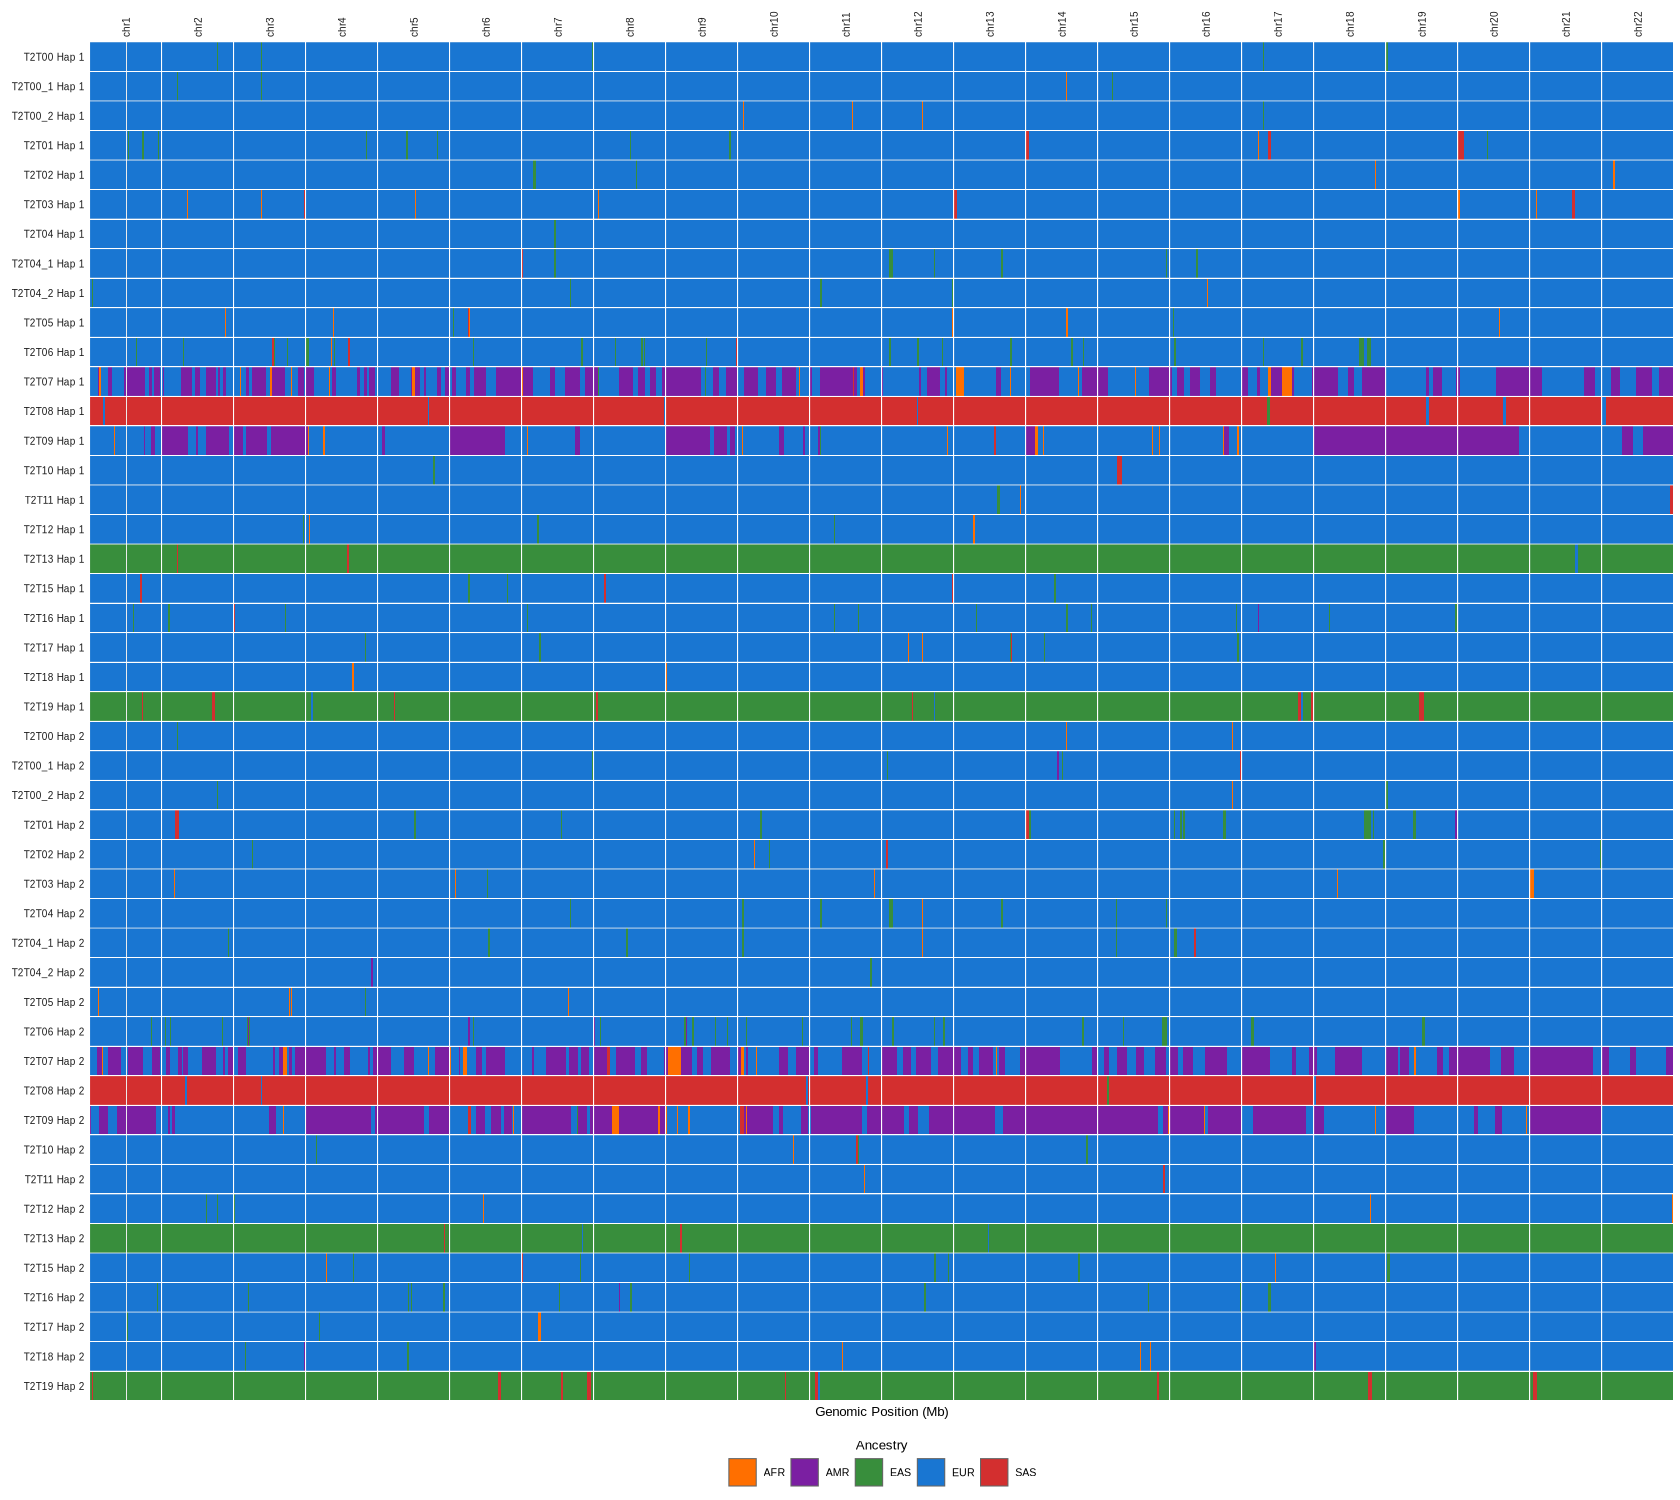

In [21]:
# Local ancestry plot: one row per sample × haplotype, facets = chromosomes
fig2_local_ancestry <- ggplot() +
    # Grey background per chromosome (full extent)
    geom_rect(
        data = chr_lengths,
        aes(xmin = 0, xmax = chr_end, ymin = -Inf, ymax = Inf),
        fill = "grey92", colour = NA
    ) +
    # Ancestry segments
    geom_rect(
        data = dt_rfmix,
        aes(
            xmin = startpos_genome, xmax = endpos_genome,
            ymin = 0, ymax = 1,
            fill = ancestry
        ),
        colour = NA
    ) +
    scale_fill_manual(values = superpop_colors, name = "Ancestry") +
    facet_grid(
        rows = vars(interaction(sample, haplotype_label, sep = " ")),
        cols = vars(chr),
        switch = "y",
        scales = "free_x"
    ) +
    scale_x_continuous(expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0)) +
    labs(x = "Genomic Position (Mb)", y = NULL) +
    theme_minimal(base_size = 8) +
    theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        panel.spacing = unit(0.5, "pt"),
        strip.text.x = element_text(angle = 90, hjust = 0, size = 6),
        strip.text.y.left = element_text(angle = 0, hjust = 1, size = 6),
        panel.grid = element_blank(),
        legend.position = "bottom"
    ) +
    guides(fill = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        nrow = 1,
        override.aes = list(colour = "grey40", linewidth = 0.3)
    ))

n_samples <- length(unique(paste(dt_rfmix$sample, dt_rfmix$haplotype)))
plot_h <- max(3, n_samples * 0.25 + 1)

ggsave("../../doc/figures/fig2_local_ancestry.png", fig2_local_ancestry,
    width = 14, height = plot_h, dpi = 150)
ggsave("../../doc/figures/fig2_local_ancestry.pdf", fig2_local_ancestry,
    width = 14, height = plot_h)

options(repr.plot.width = 14, repr.plot.height = plot_h)
fig2_local_ancestry


## Global Ancestry Summary

Stacked bar plot showing the proportion of each ancestry across the whole genome per sample (both haplotypes combined).


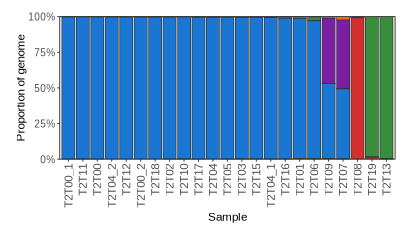

In [27]:
# Summarise: total Mb per ancestry per sample (both haplotypes combined)
dt_global <- dt_rfmix %>%
    group_by(sample, ancestry) %>%
    summarise(total_mb = sum(seg_length_mb), .groups = "drop") %>%
    group_by(sample) %>%
    mutate(proportion = total_mb / sum(total_mb)) %>%
    ungroup()

# Order samples by EUR proportion descending (common convention)
sample_order <- dt_global %>%
    filter(ancestry == "EUR") %>%
    arrange(desc(proportion)) %>%
    pull(sample)

dt_global <- dt_global %>%
    mutate(sample = factor(sample, levels = sample_order))

fig2_global_ancestry <- ggplot(dt_global, aes(x = sample, y = proportion, fill = ancestry)) +
    geom_bar(stat = "identity", colour = "grey20", linewidth = 0.2) +
    scale_fill_manual(values = superpop_colors, name = "Ancestry") +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        expand = c(0, 0),
        name = "Proportion of genome"
    ) +
    labs(x = "Sample") +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7),
        legend.position = "none",
        panel.grid.major.x = element_blank()
    ) +
    theme(legend.position = "none")

ggsave("../../doc/figures/fig2_global_ancestry.png", fig2_global_ancestry, width = 3.5, height = 2)
ggsave("../../doc/figures/fig2_global_ancestry.pdf", fig2_global_ancestry, width = 3.5, height = 2)

options(repr.plot.width = 3.5, repr.plot.height = 2)
fig2_global_ancestry
